### Generates scatter plots to visualize solver failure points.

This script queries a benchmark database to identify interior-point method (IPM) iterations where the solver's residual norm exceeded the PCG tolerance. It then creates a grid of scatter plots, one for each solver, showing these failure points as a function of the problem size (number of edges).

In [313]:
import sqlite3
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import argparse
import re
import numpy as np

In [314]:
def query_failure_points(db_path):
    conn = sqlite3.connect(f"file:{db_path}?mode=ro", uri=True)
    query = """
    WITH data AS (
        SELECT
            p.name AS problem_name,
            p.num_edges,
            r.solver_name,
            c.id AS config_id,
            c.precision,
            r.iters,
            sh.ipm_iter,
            sh.absolute_residual_norm,
            sh.relative_residual_norm,
            COALESCE(c.pcg_tol, 5e-8) AS pcg_tol
        FROM
            solver_history sh
        JOIN
            runs r ON sh.run_id = r.id
        JOIN
            problems p ON r.problem_id = p.id
        JOIN
            configs c ON r.config_id = c.id
    )
    SELECT *,
    (relative_residual_norm > pcg_tol AND absolute_residual_norm > 1e-15) AS is_failure
    FROM data
    ORDER BY problem_name, solver_name, ipm_iter;
    """
    df = pl.read_database(query, conn)
    conn.close()
    print(f"Data loaded from database: {df}")
    return df

In [315]:
def plot_failure_points(db_path, problem_pattern=None, solver_pattern=None):
    df = query_failure_points(db_path)

    if df.is_empty():
        print("No failures found matching the criteria.")
        return

    df = df.filter(pl.col("num_edges") > 1000000)
    if problem_pattern:
        df = df.filter(
            pl.col("problem_name").str.contains(problem_pattern, strict=False)
        )
    if solver_pattern:
        df = df.filter(pl.col("solver_name").str.contains(solver_pattern, strict=False))

    if df.is_empty():
        print(
            f"No data found after applying filters (problem_pattern='{problem_pattern}', solver_pattern='{solver_pattern}')."
        )
        return

    unique_solvers = df["solver_name"].unique().sort().to_list()
    # Get unique precisions (order: Float64, Float128, Float64x2, rest)
    unique_precisions = df["precision"].unique().to_list()
    precision_order = {"Float64": 0, "Float128": 1, "Float64x2": 2}
    # build a small DataFrame of unique configs, add numeric rank for precision, sort by rank then solver_name
    unique_configs_df = (
        df.select(["config_id", "solver_name", "precision"])
          .unique()
          .with_columns(
              pl.when(pl.col("precision") == "Float64").then(0)
                .when(pl.col("precision") == "Float128").then(1)
                .when(pl.col("precision") == "Float64x2").then(2)
                .otherwise(3)
                .alias("precision_rank")
          )
    )
    unique_configs = unique_configs_df.sort(by=["precision_rank", "solver_name"]).select("config_id").to_series().to_list()

    # Get unique problems and their num_edges for sorting
    problem_edges_df = df.group_by("problem_name").agg(pl.col("num_edges").first())
    sorted_problems = problem_edges_df.sort("num_edges")["problem_name"].to_list()
    unique_problems = sorted_problems # Use sorted problems

    # Create a numerical mapping for problem names for the x-axis
    problem_to_x_map = {problem: i for i, problem in enumerate(unique_problems)}
    x_ticks = list(problem_to_x_map.values())
    x_labels = list(problem_to_x_map.keys())

    colors = plt.get_cmap("Dark2", len(unique_configs))
    config_color_map = { config: colors(i) for i, config in enumerate(unique_configs) }

    config_label_map = {
        row['config_id']: f"{row['solver_name'].removeprefix('tulip_')}, {row['precision']}" 
        for row in df.select(["config_id", "solver_name", "precision"]).unique().iter_rows(named=True)
    }

    markers = ['o', 's', 'D', '^', 'v', '<']
    precision_marker_map = { precision: markers[i % len(markers)] for i, precision in enumerate(unique_precisions) }

    fig, ax = plt.subplots(figsize=(15, 8), dpi=300)

    # Add alternating background strips for each problem group (centered on the integer x positions).
    # The strips span [i-0.5, i+0.5] for problem index i and are drawn behind points (zorder=0).
    for i in range(len(unique_problems)):
        left = i - 0.5
        right = i + 0.5
        if i % 2 == 0:
            ax.axvspan(left, right, color="lightgray", alpha=0.2, zorder=0)

    # Define the width for config groups and the offsets for each config group
    num_base_configs = len(unique_configs)
    config_group_total_width = 0.8
    config_group_offsets = np.linspace(-config_group_total_width / 2, config_group_total_width / 2, num_base_configs)
    config_offset_map = {config: offset for config, offset in zip(unique_configs, config_group_offsets)}

    # Width for individual configs within a solver group.
    config_width = (config_group_total_width / num_base_configs) if num_base_configs > 0 else 0
    
    for problem_idx, problem in enumerate(unique_problems):
        problem_x_pos = problem_to_x_map[problem]
        problem_df = df.filter(pl.col("problem_name") == problem)

        # ax.axvline(problem_x_pos - 0.5, color='dimgray', linestyle='-', linewidth=0.5)

        for config_id, config_group_offset in config_offset_map.items():
            config_problem_df = problem_df.filter(pl.col("config_id") == config_id)
            if config_problem_df.is_empty():
                continue

            problem_config_df = config_problem_df.filter(pl.col("config_id") == config_id)
            if problem_config_df.is_empty():
                continue

            # Final x position for the points
            x_position = problem_x_pos + config_group_offset
            
            problem_config_failure_df = problem_config_df.filter(pl.col("is_failure") == True)
            if not problem_config_failure_df.is_empty():
                ax.scatter(
                    [x_position] * len(problem_config_failure_df),
                    problem_config_failure_df["ipm_iter"],
                    color=config_color_map[config_id],
                    alpha=0.8,
                    s=10,
                    marker='x',
                    zorder=3,
                )

            if not problem_config_df["iters"].is_empty():
                iters_value = problem_config_df["iters"].unique().to_list()[0]
                
                # The width of the hline should be small, representing a single config point
                ax.hlines(y=iters_value, xmin=x_position - config_width / 2, 
                            xmax=x_position + config_width / 2, 
                            color=config_color_map[config_id], linestyle='-', linewidth=1.5, zorder=3)

    # ax.axvline(len(unique_problems) - 0.5, color='dimgray', linestyle='-', linewidth=0.5)

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=45, ha="right")
    ax.set_xlabel("Problem Name", fontsize=12)
    ax.set_ylabel("IPM Iteration", fontsize=12)
    ax.set_title("IPM Iterations at which Residual Norm > pcg_tol", fontsize=14)
    ax.grid(True, which="both", ls="--")
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.tick_params(axis="both", which="minor", labelsize=8)

    # Create custom legend
    from matplotlib.lines import Line2D
    legend_elements = []
    for config_id in unique_configs:
        legend_elements.append(Patch(facecolor=config_color_map[config_id], label=config_label_map[config_id]))

    ax.legend(handles=legend_elements, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0., fontsize=8)

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

Data loaded from database: shape: (13_402, 11)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ problem_n ┆ num_edges ┆ solver_na ┆ config_id ┆ … ┆ absolute_ ┆ relative_ ┆ pcg_tol   ┆ is_failu │
│ ame       ┆ ---       ┆ me        ┆ ---       ┆   ┆ residual_ ┆ residual_ ┆ ---       ┆ re       │
│ ---       ┆ i64       ┆ ---       ┆ i64       ┆   ┆ norm      ┆ norm      ┆ f64       ┆ ---      │
│ str       ┆           ┆ str       ┆           ┆   ┆ ---       ┆ ---       ┆           ┆ i64      │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆ f64       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ grid_h5_w ┆ 18010     ┆ tulip_app ┆ 1         ┆ … ┆ 8.5789e-8 ┆ 1.8732e-8 ┆ 5.0000e-8 ┆ 0        │
│ 1000      ┆           ┆ roxchol   ┆           ┆   ┆           ┆           ┆           ┆          │
│ grid_h5_w ┆ 18010     ┆ tulip_app ┆ 1     

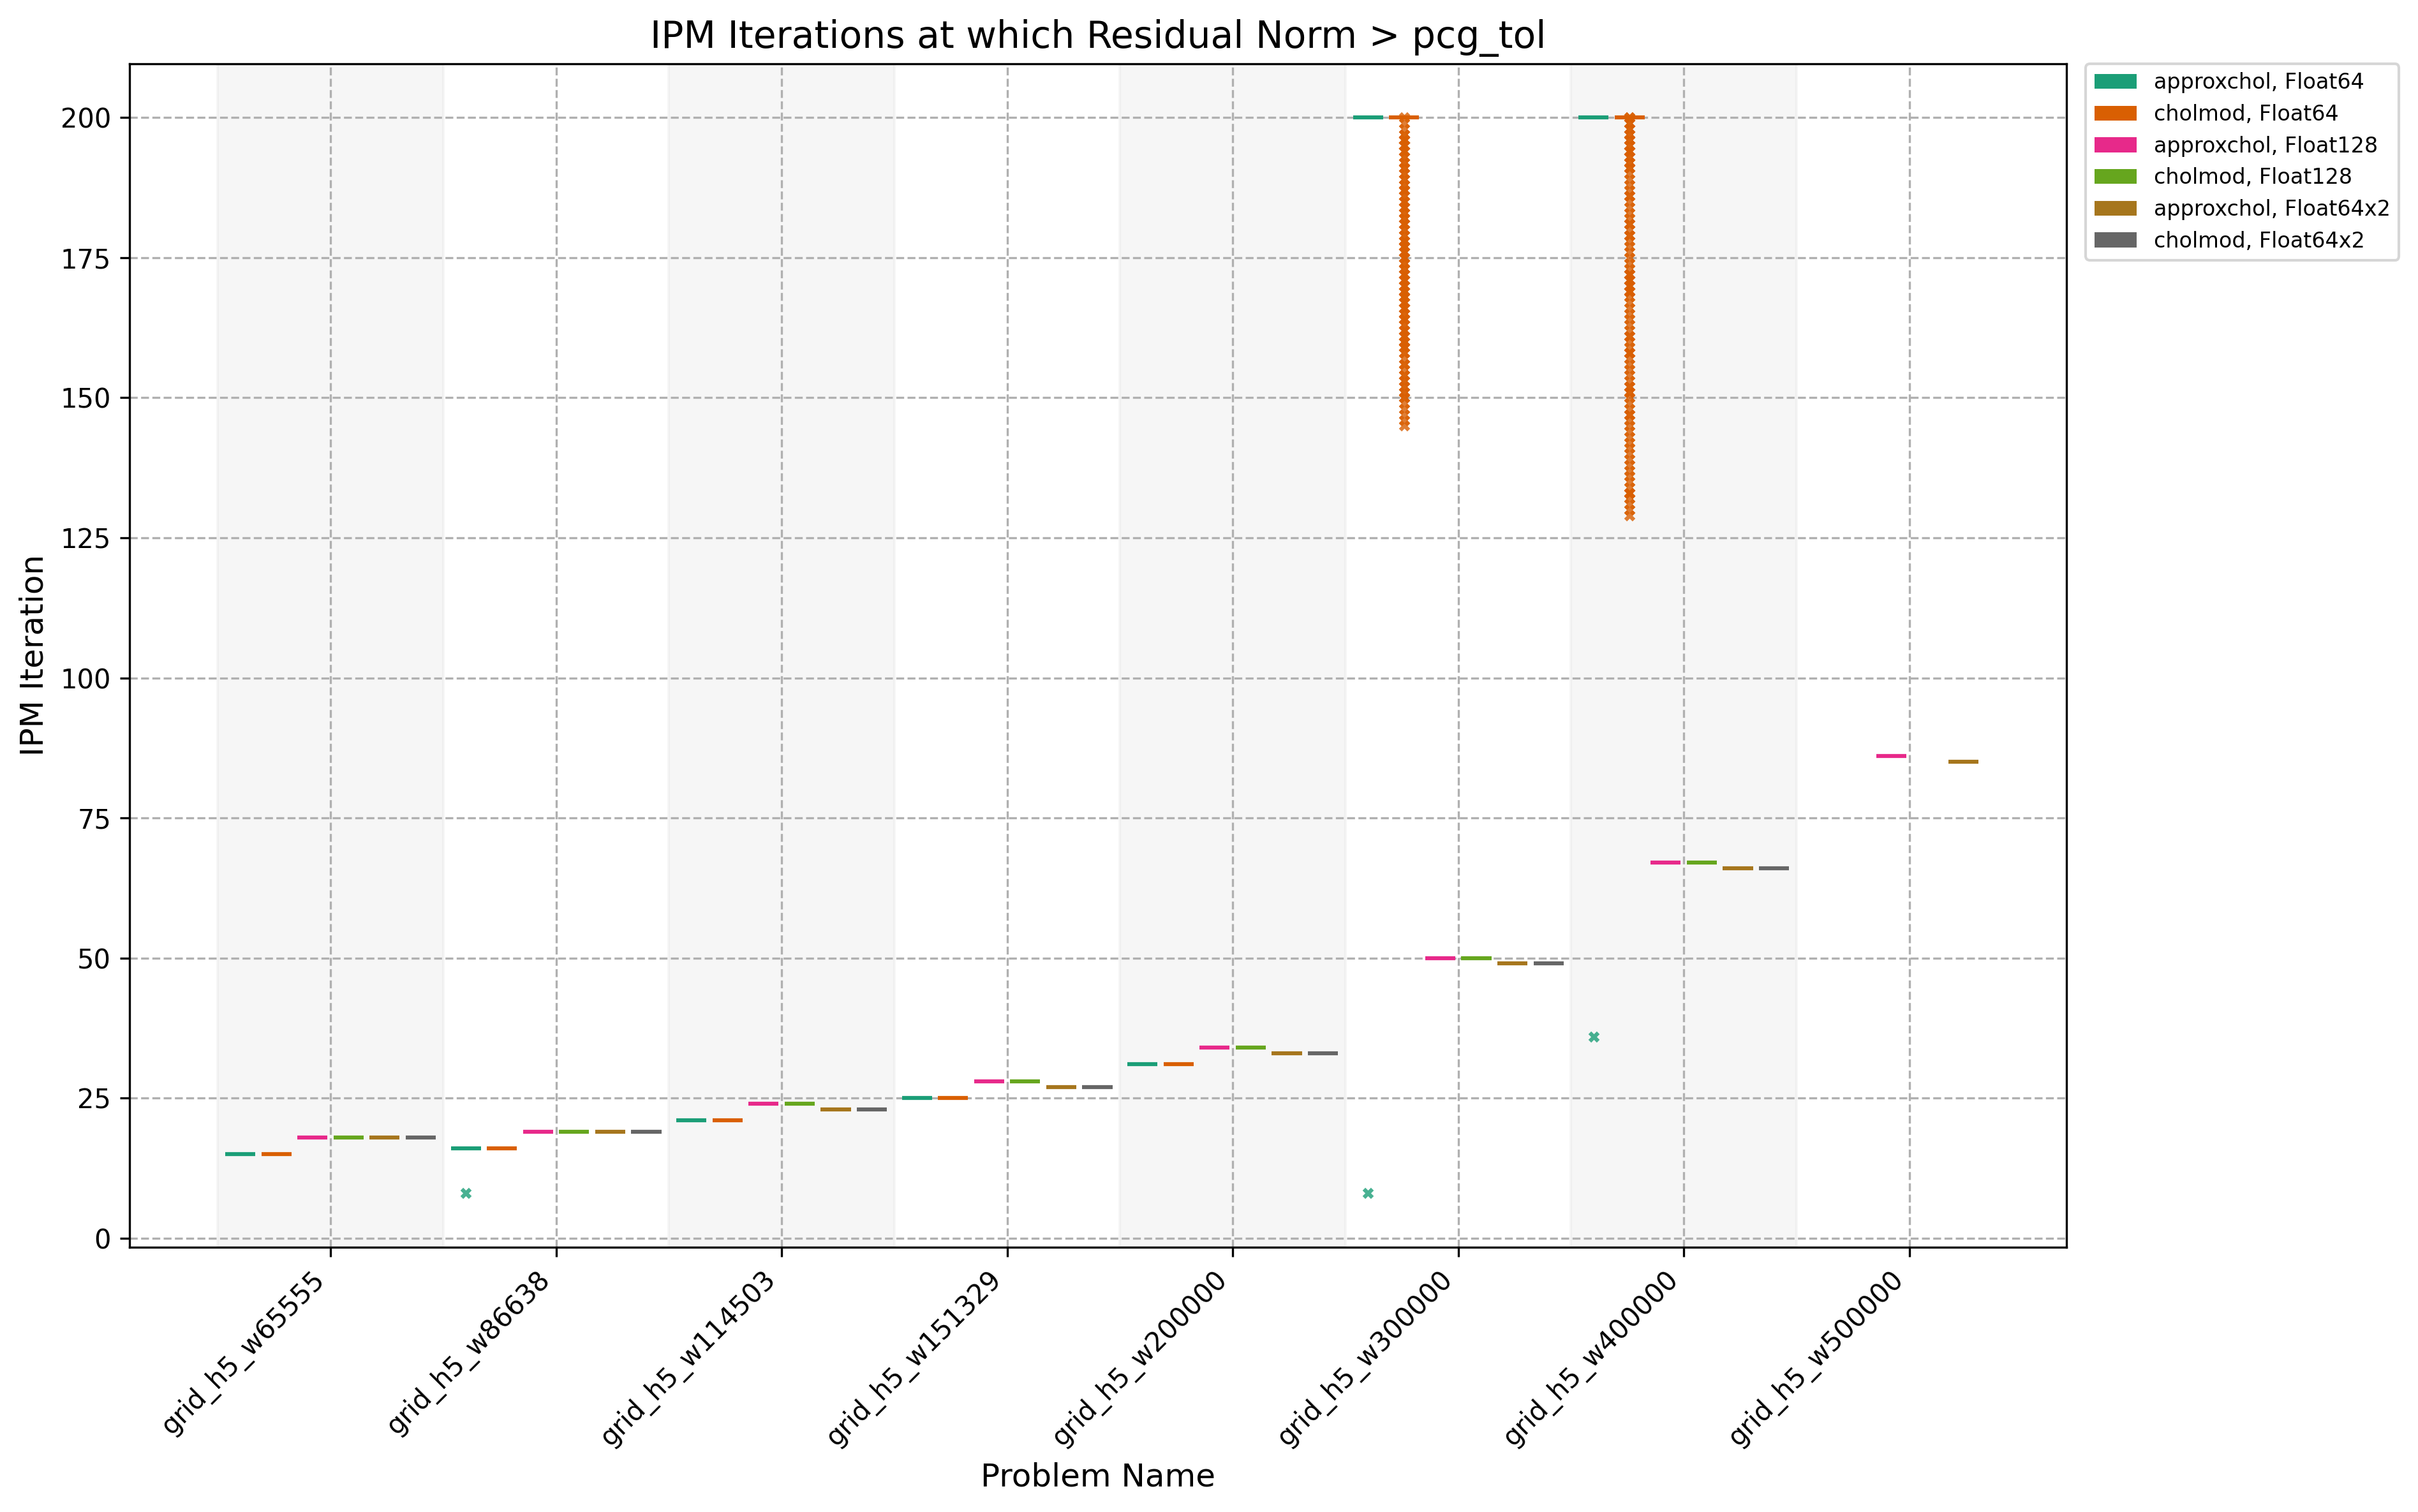

In [316]:
plot_failure_points("../unifwidegrid.db") # Assuming a default db file for demonstration